In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from pathlib import Path
import Production.sr_signal as sr_signal
import math

In [2]:
OUTPUT_DIR = Path("railway_figures")
OUTPUT_DIR.mkdir(exist_ok=True)

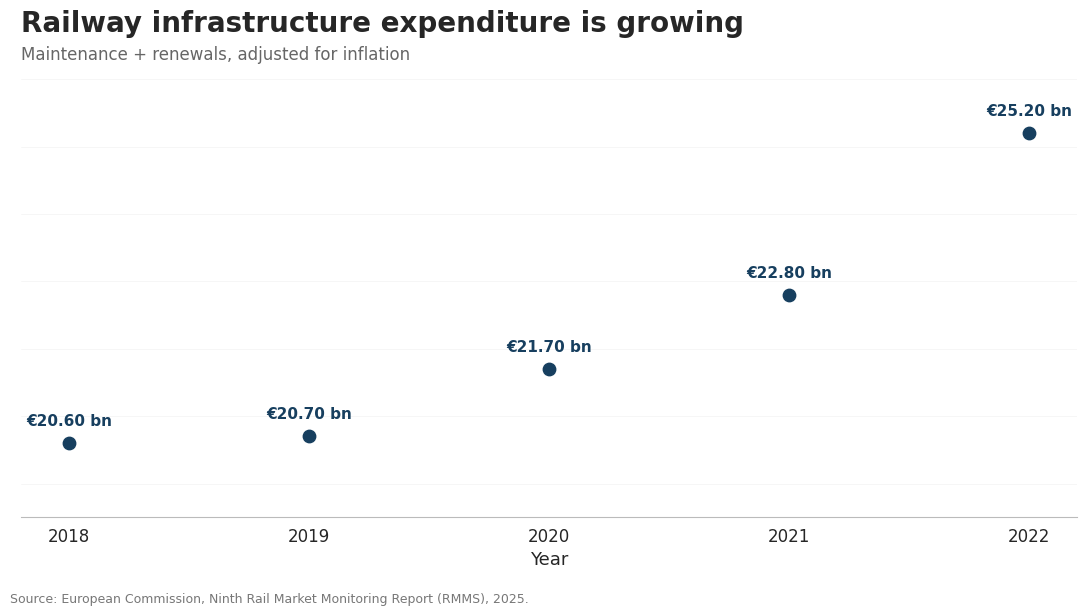

In [4]:
# ============================================================
# 1. EU27 infrastructure maintenance
# ============================================================

years_eu = np.array([2018, 2019, 2020, 2021, 2022])

maintenance_eu = np.array([
    20.6,
    20.7,
    21.7,
    22.8,
    25.2
])

fig, ax = plt.subplots(figsize=(11, 6.2))

# Main trend line
ax.scatter(
    years_eu,
    maintenance_eu,
    s=80,
    color="#173F5F",
    zorder=3
)

# Subtle horizontal grid
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Remove unnecessary borders
ax.spines["bottom"].set_color("#BBBBBB")

# Labels on each point
for x, y in zip(years_eu, maintenance_eu):
    ax.annotate(
        f"€{y:.2f} bn",
        xy=(x, y),
        xytext=(0, 13),
        textcoords="offset points",
        ha="center",
        fontsize=11,
        color="#173F5F",
        fontweight="bold",
    )

# Titles
ax.set_title(
    "Railway infrastructure expenditure is growing",
    loc="left",
    pad=20,
    fontweight="bold",
)

ax.text(
    0,
    1.0,
    "Maintenance + renewals, adjusted for inflation",
    transform=ax.transAxes,
    fontsize=12,
    color="#666666",
)

# Axis formatting
ax.set_ylabel("")
ax.tick_params(axis="y", labelleft=False)
ax.yaxis.grid(True)
ax.set_xlabel("Year")

ax.set_xticks(years_eu)
ax.set_ylim(19.5, 26.3)

# # Highlight the overall change
# ax.annotate(
#     "+22%",
#     xy=(2022, 12.48),
#     xytext=(2020.8, 12.95),
#     fontsize=15,
#     fontweight="bold",
#     color="#C84B31",
#     arrowprops=dict(
#         arrowstyle="->",
#         color="#C84B31",
#         lw=1.5,
#     ),
# )

# Source
fig.text(
    0.01,
    0.015,
    "Source: European Commission, Ninth Rail Market Monitoring Report (RMMS), 2025.",
    fontsize=9,
    color="#777777",
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

# Vector formats for PowerPoint / Keynote / Illustrator
fig.savefig(
    OUTPUT_DIR / "eu_infrastructure_maintenance.pdf",
    bbox_inches="tight",
)
fig.savefig(
    OUTPUT_DIR / "eu_infrastructure_maintenance.svg",
    bbox_inches="tight",
)

plt.show()

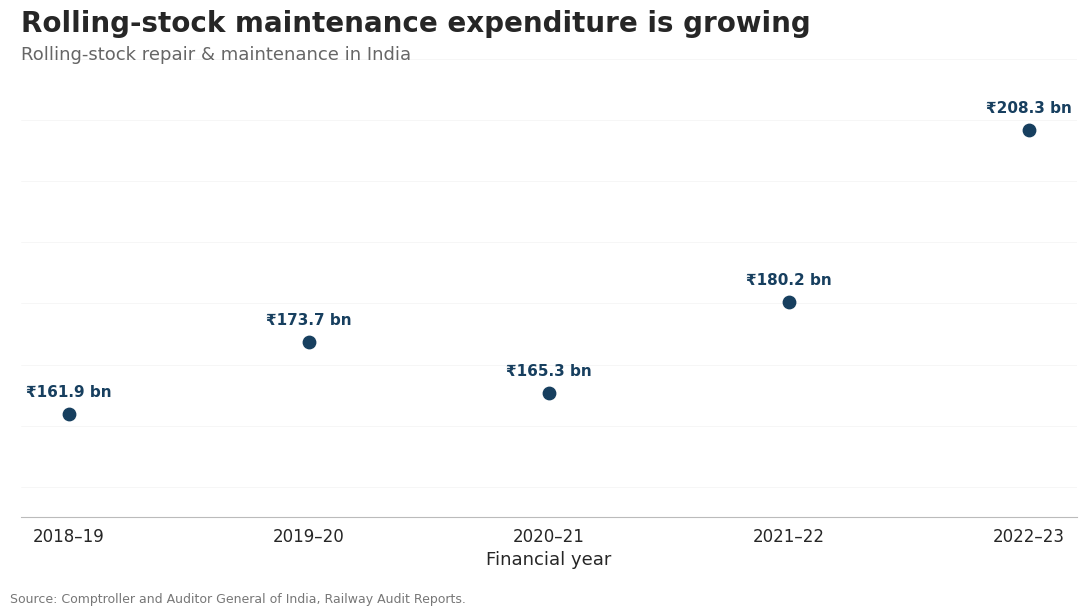

In [5]:
# ============================================================
# 2. Indian Railways rolling-stock maintenance
# ============================================================

years_india = np.array([
    "2018–19",
    "2019–20",
    "2020–21",
    "2021–22",
    "2022–23"
])

maintenance_india = np.array([
    161.8715,
    173.6821,
    165.3137,
    180.1806,
    208.3341
])

fig, ax = plt.subplots(figsize=(11, 6.2))

ax.scatter(
    years_india,
    maintenance_india,
    s=80,
    color="#173F5F",
    zorder=3
)

ax.yaxis.grid(True)
ax.xaxis.grid(False)

ax.spines["bottom"].set_color("#BBBBBB")

# Data labels
for i, y in enumerate(maintenance_india):
    ax.annotate(
        f"₹{y:.1f} bn",
        xy=(i, y),
        xytext=(0, 13),
        textcoords="offset points",
        ha="center",
        fontsize=11,
        color="#173F5F",
        fontweight="bold",
    )

ax.set_title(
    "Rolling-stock maintenance expenditure is growing",
    loc="left",
    pad=20,
    fontweight="bold",
)

ax.text(
    0,
    1,
    "Rolling-stock repair & maintenance in India",
    transform=ax.transAxes,
    fontsize=13,
    color="#666666",
)

ax.set_ylabel("")
ax.tick_params(axis="y", labelleft=False)
ax.yaxis.grid(True)
ax.set_xlabel("Financial year")

ax.set_ylim(145, 220)

# Overall increase
increase = (
    (maintenance_india[-1] / maintenance_india[0]) - 1
) * 100

# ax.annotate(
#     f"+{increase:.0f}%",
#     xy=(4, maintenance_india[-1]),
#     xytext=(3.1, 214),
#     fontsize=15,
#     fontweight="bold",
#     color="#C84B31",
#     arrowprops=dict(
#         arrowstyle="->",
#         color="#C84B31",
#         lw=1.5,
#     ),
# )

fig.text(
    0.01,
    0.015,
    "Source: Comptroller and Auditor General of India, Railway Audit Reports.",
    fontsize=9,
    color="#777777",
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

fig.savefig(
    OUTPUT_DIR / "indian_railways_rolling_stock_maintenance.pdf",
    bbox_inches="tight",
)
fig.savefig(
    OUTPUT_DIR / "indian_railways_rolling_stock_maintenance.svg",
    bbox_inches="tight",
)

plt.show()

In [3]:
# Simulation data
path = r"C:\Users\prife\OneDrive - KTH\KTH\04 Research\01 Conferences\2026\Railways\01 Simulations\main_model\output"
scenarios = ["S7_IRREG1_K1", "S8_IRREG1_K0d7", "S9_IRREG1_K0d5", "S10_IRREG1_K1d35", "S11_IRREG2_K1"]
sensor_names = ["B1_right"]
scenario = "S7_IRREG1_K1"
sensor_name = sensor_names[0]

segment = 32

fs = 50  # Hz

scenario_data = {}

for scenario in scenarios:
    scenario_data[scenario] = sr_signal.load_data(path, scenario)

acceleration, time, dist = scenario_data[scenario][sensor_name]

# segmentation
seg_len_sec = 16.0
seg_hop_sec = 1.6  # 90% overlap
seg_len_samples = int(seg_len_sec * fs)  # 800
seg_hop_samples = int(seg_hop_sec * fs)  # 80

segments = []  # list of (seg_signal, seg_start_time, seg_index) tuples

N = len(acceleration)
seg_index = 0
start = 0
while start + seg_len_samples <= N:
    end = start + seg_len_samples
    seg_signal = acceleration[start:end]
    seg_start_time = time[start]  # absolute time from simulation start
    segments.append((seg_signal, seg_start_time, seg_index))
    seg_index += 1
    start += seg_hop_samples


seg_signal, seg_start_time, seg_index = segments[segment]
stft_magnitude, peaks, frame_times, freqs = sr_signal.process_signal(seg_signal)

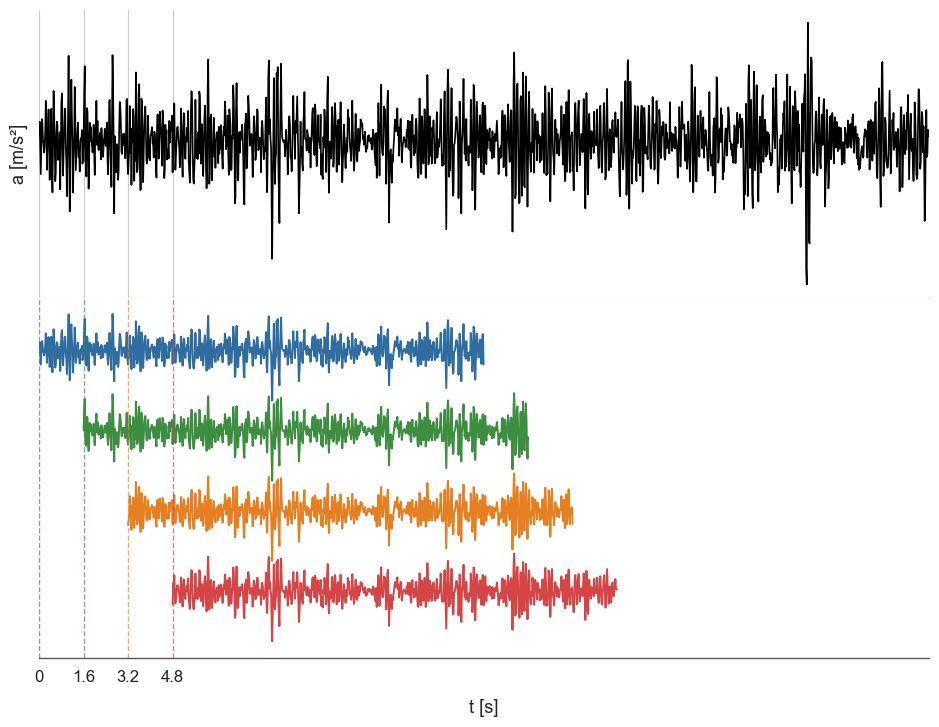

In [4]:
# ============================================================
# Plot only the first 32 seconds
# ============================================================
plot_duration = 32.0

mask = time <= time[0] + plot_duration

t_plot = time[mask]
a_plot = acceleration[mask]

# Shift time so that the plot starts at t = 0
t_plot = t_plot - time[0]

# Shift segment start times into the same relative time frame
segment_data = []

for seg_signal, seg_start_time, seg_index in segments:
    relative_start = seg_start_time - time[0]

    # Only keep segments that start within the first 32 s
    if relative_start < plot_duration:
        segment_data.append(
            (seg_signal, relative_start, seg_index)
        )


# ============================================================
# Figure
# ============================================================
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(10, 8),                  # wider for PowerPoint
    gridspec_kw={"height_ratios": [1, 1.25]},
    sharex=True
)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.94,
    bottom=0.13,
    hspace=0
)


# ============================================================
# Top: continuous signal
# ============================================================
ax_top.plot(
    t_plot,
    a_plot,
    linewidth=1.2,                   # thicker than before
    color="black",
    solid_capstyle="round"
)

ax_top.set_ylabel(
    "a [m/s²]",
    fontsize=13,
    labelpad=8
)

ax_top.set_xlim(0, plot_duration)

ax_top.set_yticks([])

# Clean axes
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.spines["left"].set_visible(False)

# Remove x-axis from top plot
ax_top.tick_params(
    axis="x",
    which="both",
    bottom=False,
    labelbottom=False
)


# ============================================================
# Bottom: overlapping segments
# ============================================================

n_segments_to_show = 4
segments_to_show = segment_data[:n_segments_to_show]

# Determine vertical separation
signal_range = (
    np.percentile(a_plot, 99)
    - np.percentile(a_plot, 1)
)

offset = signal_range * 1.35

# Store segment start times
segment_start_times = []


# ============================================================
# Segment colours
# ============================================================
segment_colors = [
    "#2F6DA1",  # blue
    "#3E8E41",  # green
    "#E67E22",  # orange
    "#D64545",  # red
]


for i, (seg_signal, seg_start, seg_index) in enumerate(
    segments_to_show
):

    segment_start_times.append(seg_start)

    # Time axis for this segment
    seg_time = (
        np.arange(len(seg_signal)) / fs
        + seg_start
    )

    # Don't draw beyond 32 s
    valid = seg_time <= plot_duration

    # Vertical position
    y_offset = -i * offset

    ax_bottom.plot(
        seg_time[valid],
        seg_signal[valid] + y_offset,
        linewidth=1.4,                # thicker for PPT
        color=segment_colors[i],
        solid_capstyle="round"
    )

    # Segment start marker
    ax_bottom.axvline(
        seg_start,
        linestyle="--",
        linewidth=1.0,                # stronger marker
        color=segment_colors[i],
        alpha=0.65
    )


# ============================================================
# Bottom-axis formatting
# ============================================================

ax_bottom.set_xlabel(
    "t [s]",
    fontsize=13,
    labelpad=10
)

ax_bottom.set_xlim(0, plot_duration)

# Only show segment start times
ax_bottom.set_xticks(segment_start_times)

ax_bottom.set_xticklabels(
    [f"{t:g}" for t in segment_start_times],
    fontsize=12
)

# No tick marks — labels float cleanly below the axis
ax_bottom.tick_params(
    axis="x",
    which="both",
    length=0,
    pad=9,
    labelsize=12
)

ax_bottom.set_yticks([])

# Remove unnecessary grid
ax_bottom.grid(False)

# Clean axes
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["right"].set_visible(False)
ax_bottom.spines["left"].set_visible(False)

# Make the remaining x-axis spine more visible
ax_bottom.spines["bottom"].set_color("0.35")
ax_bottom.spines["bottom"].set_linewidth(1.0)


# ============================================================
# Save as SVG
# ============================================================
fig.savefig(
    OUTPUT_DIR / "segmentation.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [9]:
frame_idx = 7
frame = stft_magnitude[:, frame_idx]
window = 3
half_window = window // 2
local_max = np.zeros(len(frame), dtype=bool)

for i in range(half_window, len(frame) - half_window):
    if frame[i] == np.max(frame[i-half_window:i+half_window+1]) and frame[i] > 0:
        local_max[i] = True

_, band_masks, band_weights = sr_signal.peaks(stft_magnitude, frame_times, 5, freqs)

peak_indices = np.where(local_max)[0]
peak_magnitudes = frame[peak_indices]

weights = np.ones(len(peak_indices))
for band_name, band_mask in band_masks.items():
    weights[band_mask[peak_indices]] = band_weights[band_name]

weighted_magnitudes = peak_magnitudes * weights

peaks_sorted = sorted(peaks, key=lambda p: p[1])
start_idx = frame_idx * 5
end_idx = start_idx + 5

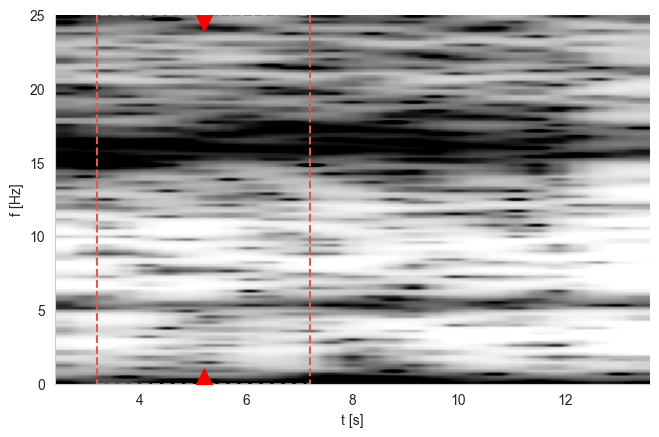

In [6]:
# ============================================================
# Parameters
# ============================================================
dt = 4.0  # highlighted frame duration [s]

frame_start = frame_times[frame_idx] - dt / 2
frame_end   = frame_times[frame_idx] + dt / 2


# ============================================================
# Convert magnitude to dB
# ============================================================
mag_db = 10 * np.log10(stft_magnitude + 1e-12)

# Robust contrast range
vmin = np.percentile(mag_db, 5)
vmax = np.percentile(mag_db, 95)


# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(
    figsize=(7, 4.5)
)

fig.subplots_adjust(
    left=0.12,
    right=0.97,
    bottom=0.15,
    top=0.97
)


# ============================================================
# Spectrogram
# ============================================================
im = ax.imshow(
    mag_db,
    aspect="auto",
    origin="lower",
    extent=[
        frame_times[0],
        frame_times[-1],
        freqs[0],
        freqs[-1]
    ],
    vmin=vmin,
    vmax=vmax,
    cmap="Greys_r"
)


# ============================================================
# Highlight selected frame
# ============================================================
rect = Rectangle(
    (frame_start, freqs[0]),
    dt,
    freqs[-1] - freqs[0],
    linewidth=1.5,
    edgecolor="#E15759",
    facecolor="none",
    linestyle="--",
    zorder=5
)

ax.add_patch(rect)

# bottom triangle (pointing up)
ax.scatter(
    frame_times[frame_idx],
    freqs[0],
    marker="^",
    color="red",
    s=500,
    zorder=7
)

# top triangle (pointing down)
ax.scatter(
    frame_times[frame_idx],
    freqs[-1],
    marker="v",
    color="red",
    s=500,
    zorder=7
)

# ============================================================
# Axes
# ============================================================
ax.set_xlabel("t [s]")
ax.set_ylabel("f [Hz]")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)


# # ============================================================
# # Colorbar
# # ============================================================
# cbar = fig.colorbar(
#     im,
#     ax=ax,
#     pad=0.02,
#     fraction=0.045
# )
#
# cbar.set_label("Magnitude [dB]")
#
# cbar.outline.set_visible(False)


plt.show()


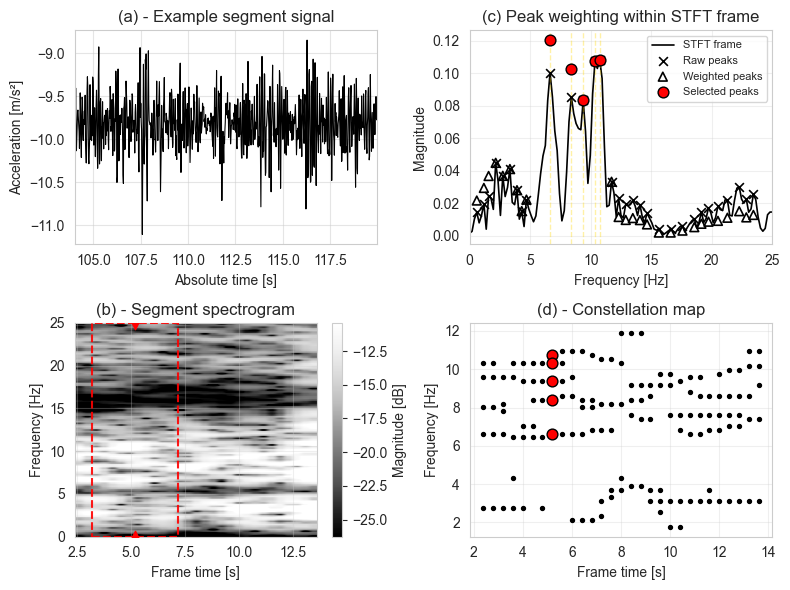

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

# =========================
# (a) Time-domain signal — TOP LEFT
# =========================
ax_t = axs[0, 0]

seg_time = seg_start_time + np.arange(seg_len_samples) * (time[1] - time[0])

ax_t.plot(seg_time, seg_signal, color="black", linewidth=0.8)
ax_t.set_ylabel("Acceleration [m/s²]")
ax_t.set_xlabel("Absolute time [s]")
ax_t.set_xlim(seg_time[0],seg_time[-1])
ax_t.set_title("(a) - Example segment signal")
ax_t.grid(True, alpha=0.5)


# =========================
# Spectrogram only — BOTTOM LEFT
# =========================
ax_spec = axs[1, 0]

dt = 4

frame_start = frame_times[frame_idx] - dt / 2
frame_end   = frame_times[frame_idx] + dt / 2

mag_db = 10 * np.log10(stft_magnitude + 1e-12)
vmin = np.percentile(mag_db, 5)
vmax = np.percentile(mag_db, 95)

im = ax_spec.imshow(
    mag_db,
    aspect="auto",
    origin="lower",
    extent=[frame_times[0], frame_times[-1], freqs[0], freqs[-1]],
    vmin=vmin,
    vmax=vmax,
    cmap="Greys_r"
)

rect = Rectangle(
    (frame_start, freqs[0]),      # (x, y)
    dt,                           # width  (time)
    freqs[-1] - freqs[0],         # height (frequency)
    linewidth=1.5,
    edgecolor="red",
    facecolor="none",
    linestyle="--",
    alpha=0.9,
    zorder=5
)

ax_spec.add_patch(rect)

# bottom triangle (pointing up)
ax_spec.scatter(
    frame_times[frame_idx],
    freqs[0],
    marker="^",
    color="red",
    s=80,
    zorder=7
)

# top triangle (pointing down)
ax_spec.scatter(
    frame_times[frame_idx],
    freqs[-1],
    marker="v",
    color="red",
    s=80,
    zorder=7
)

ax_spec.set_xlabel("Frame time [s]")
ax_spec.set_ylabel("Frequency [Hz]")
ax_spec.set_title("(b) - Segment spectrogram")
ax_spec.grid(True, alpha=0.3)

fig.colorbar(im, ax=ax_spec, label="Magnitude [dB]")


# =========================
# Peak weighting + selection — TOP RIGHT
# =========================
ax_pw = axs[0, 1]

# Top-N peak selection
top_indices = np.argsort(-weighted_magnitudes)[:5]

# Masks
selected_mask = np.zeros(len(peak_indices), dtype=bool)
selected_mask[top_indices] = True
non_selected_mask = ~selected_mask

# 1) Full STFT frame
ax_pw.plot(
    freqs,
    frame,
    color="black",
    linewidth=1.2,
    label="STFT frame"
)

# 2) Raw peaks (BLUE)
ax_pw.scatter(
    freqs[peak_indices],
    frame[peak_indices],
    marker="x",
    color="black",
    s=40,
    linewidths=1.2,
    zorder=3,
    label="Raw peaks"
)

# 3) Weighted peaks – non-selected (RED)
ax_pw.scatter(
    freqs[peak_indices[non_selected_mask]],
    weighted_magnitudes[non_selected_mask],
    marker="^",
    facecolors="none",  # since it is a filled big marker, make it prettier with removing filling
    edgecolor="black",
    s=40,
    linewidths=1.2,
    zorder=4,
    label="Weighted peaks"
)

# 4) Weighted peaks – selected
ax_pw.scatter(
    freqs[peak_indices[selected_mask]],
    weighted_magnitudes[selected_mask],
    marker="o",
    facecolors="red",
    edgecolors="black",
    s=60,
    zorder=5,
    label="Selected peaks"
)

# 5) Vertical dashed lines for selected peaks
for f in freqs[peak_indices[selected_mask]]:
    ax_pw.axvline(
        f,
        color="gold",
        linestyle="--",
        alpha=0.35,
        linewidth=1
    )

ax_pw.set_xlabel("Frequency [Hz]")
ax_pw.set_ylabel("Magnitude")
ax_pw.set_xlim(freqs[0],freqs[-1])
ax_pw.set_title("(c) Peak weighting within STFT frame")

ax_pw.grid(True, alpha=0.3)
ax_pw.legend(fontsize=8)


# =========================
# Peaks in time–frequency plane — BOTTOM RIGHT
# =========================
ax_tf = axs[1, 1]

peak_freqs = np.array([p[0] for p in peaks])
peak_times = np.array([p[1] for p in peaks])
peak_freqs_sorted = np.array([p[0] for p in peaks_sorted])
peak_times_sorted = np.array([p[1] for p in peaks_sorted])

ax_tf.scatter(peak_times, peak_freqs, s=8, color="black")

ax_tf.scatter(
    peak_times_sorted[start_idx:end_idx],
    peak_freqs_sorted[start_idx:end_idx],
    s=60,
    facecolors="red",
    edgecolors="black",
    zorder=3,
    label=f"Frame {frame_idx} selected peaks"
)

ax_tf.set_xlabel("Frame time [s]")
ax_tf.set_ylabel("Frequency [Hz]")
ax_tf.set_title("(d) - Constellation map")
ax_tf.grid(True, alpha=0.3)


fig.tight_layout()
plt.show()

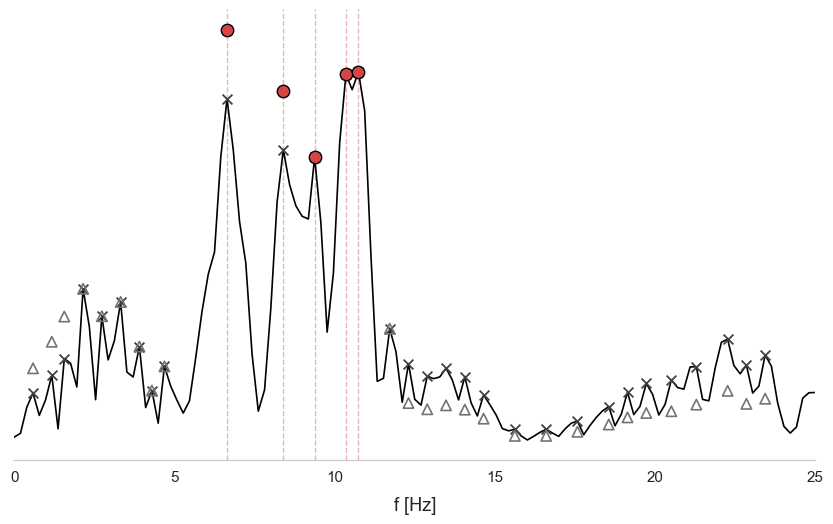

In [12]:
# ============================================================
# Top-N peak selection
# ============================================================
n_selected = 5

top_indices = np.argsort(-weighted_magnitudes)[:n_selected]

selected_mask = np.zeros(len(peak_indices), dtype=bool)
selected_mask[top_indices] = True

non_selected_mask = ~selected_mask


# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(
    figsize=(9, 5.5)                  # wider for PowerPoint
)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.14,
    top=0.96
)


# ============================================================
# Full STFT frame
# ============================================================
ax.plot(
    freqs,
    frame,
    color="black",
    linewidth=1.2,                    # thicker for visibility
    zorder=1
)


# ============================================================
# Raw peaks
# ============================================================
ax.scatter(
    freqs[peak_indices],
    frame[peak_indices],
    marker="x",
    color="0.25",
    s=50,                              # larger
    linewidths=1.3,                   # stronger marker
    zorder=3
)


# ============================================================
# Weighted peaks — non-selected
# ============================================================
ax.scatter(
    freqs[peak_indices[non_selected_mask]],
    weighted_magnitudes[non_selected_mask],
    marker="^",
    facecolors="none",
    edgecolors="0.45",
    s=55,                              # larger
    linewidths=1.2,
    zorder=4
)


# ============================================================
# Weighted peaks — selected
# ============================================================
selected_color = "#D64545"

ax.scatter(
    freqs[peak_indices[selected_mask]],
    weighted_magnitudes[selected_mask],
    marker="o",
    facecolors=selected_color,
    edgecolors="black",
    s=80,                              # substantially larger
    linewidths=1.0,
    zorder=5
)


# ============================================================
# Selected-frequency indicators
# ============================================================
for f in freqs[peak_indices[selected_mask]]:
    ax.axvline(
        f,
        color=selected_color,
        linestyle="--",
        alpha=0.40,                    # more visible
        linewidth=1.0,
        zorder=0
    )


# ============================================================
# Axes
# ============================================================
ax.set_xlabel(
    "f [Hz]",
    fontsize=13,
    labelpad=8
)

ax.set_xlim(
    freqs[0],
    freqs[-1]
)

# Remove y-axis completely
ax.set_ylabel("")
ax.set_yticks([])

ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["bottom"].set_linewidth(0.9)

ax.tick_params(
    axis="x",
    which="major",
    labelsize=11,
    length=4,
    width=0.8
)

ax.grid(False)


# ============================================================
# Save as SVG
# ============================================================
fig.savefig(
    OUTPUT_DIR / "top_n_peak_selection.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

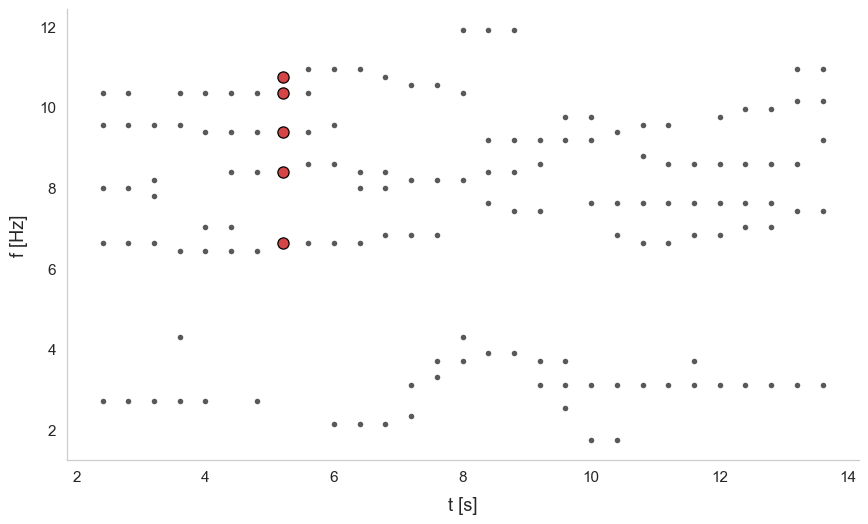

In [11]:
# ============================================================
# Peak coordinates
# ============================================================
peak_freqs = np.array([p[0] for p in peaks])
peak_times = np.array([p[1] for p in peaks])

peak_freqs_sorted = np.array([p[0] for p in peaks_sorted])
peak_times_sorted = np.array([p[1] for p in peaks_sorted])


# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(
    figsize=(9, 5.5)                  # wider for PowerPoint
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.14,
    top=0.96
)


# ============================================================
# All detected peaks
# ============================================================
ax.scatter(
    peak_times,
    peak_freqs,
    s=16,                              # slightly larger
    color="0.35",                      # softer than pure black
    linewidths=0,
    zorder=1
)


# ============================================================
# Selected peaks
# ============================================================
selected_color = "#D64545"

ax.scatter(
    peak_times_sorted[start_idx:end_idx],
    peak_freqs_sorted[start_idx:end_idx],
    s=65,                              # larger for visibility
    facecolors=selected_color,
    edgecolors="black",
    linewidths=0.9,
    zorder=3
)


# ============================================================
# Axes
# ============================================================
ax.set_xlabel(
    "t [s]",
    fontsize=13,
    labelpad=8
)

ax.set_ylabel(
    "f [Hz]",
    fontsize=13,
    labelpad=8
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    length=4,
    width=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.9)
ax.spines["bottom"].set_linewidth(0.9)

ax.grid(False)


# ============================================================
# Save as SVG
# ============================================================
fig.savefig(
    OUTPUT_DIR / "peak_selection.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

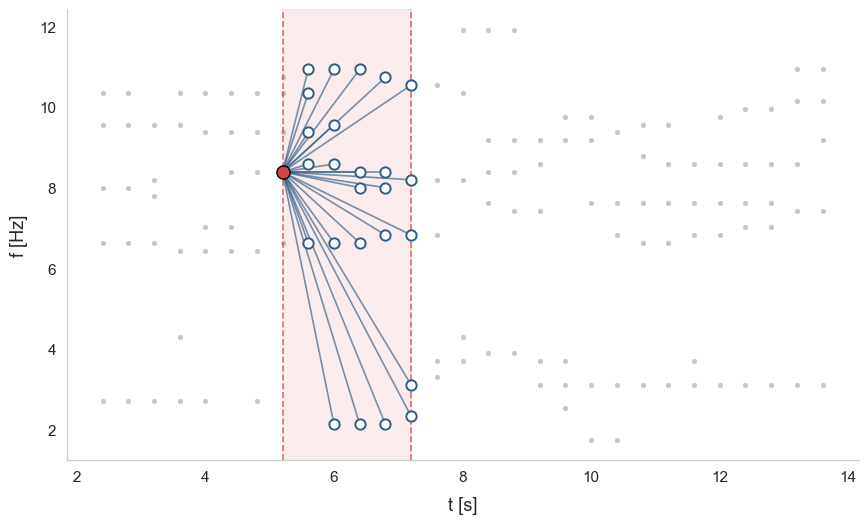

In [21]:
# ============================================================
# Sort peaks by time
# ============================================================
peaks_sorted = sorted(peaks, key=lambda p: p[1])

peak_freqs = np.array([p[0] for p in peaks_sorted])
peak_times = np.array([p[1] for p in peaks_sorted])


# ============================================================
# Choose anchor
# ============================================================
anchor_idx = 38

t1 = peak_times[anchor_idx]
f1 = peak_freqs[anchor_idx]


# ============================================================
# Identify target peaks within time window
# ============================================================
time_window_sec = 2.0

is_target = (
    (peak_times > t1) &
    (peak_times <= t1 + time_window_sec)
)

target_times = peak_times[is_target]
target_freqs = peak_freqs[is_target]


# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(
    figsize=(9, 5.5)                  # wider for PowerPoint
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.14,
    top=0.96
)


# ============================================================
# All peaks
# ============================================================
ax.scatter(
    peak_times,
    peak_freqs,
    s=14,                              # slightly larger
    color="0.45",
    alpha=0.40,
    linewidths=0,
    zorder=1
)


# ============================================================
# Pairing window
# ============================================================
selected_color = "#D64545"
connection_color = "#2F5D85"

ax.axvspan(
    t1,
    t1 + time_window_sec,
    color=selected_color,
    alpha=0.10,                        # more visible
    zorder=0
)

ax.axvline(
    t1,
    color=selected_color,
    linestyle="--",
    linewidth=1.2,
    alpha=0.75,
    zorder=2
)

ax.axvline(
    t1 + time_window_sec,
    color=selected_color,
    linestyle="--",
    linewidth=1.2,
    alpha=0.75,
    zorder=2
)


# ============================================================
# Connections from anchor to target peaks
# ============================================================
for t, f in zip(target_times, target_freqs):

    ax.plot(
        [t1, t],
        [f1, f],
        color=connection_color,
        linewidth=1.2,                  # stronger connections
        alpha=0.65,
        zorder=2
    )


# ============================================================
# Target peaks
# ============================================================
ax.scatter(
    target_times,
    target_freqs,
    s=55,                              # larger target markers
    facecolors="white",
    edgecolors=connection_color,
    linewidths=1.4,
    zorder=4
)


# ============================================================
# Anchor peak
# ============================================================
ax.scatter(
    t1,
    f1,
    s=90,                              # larger anchor
    color=selected_color,
    edgecolors="black",
    linewidths=1.0,
    zorder=5
)


# ============================================================
# Axes
# ============================================================
ax.set_xlabel(
    "t [s]",
    fontsize=13,
    labelpad=8
)

ax.set_ylabel(
    "f [Hz]",
    fontsize=13,
    labelpad=8
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    length=4,
    width=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.9)
ax.spines["bottom"].set_linewidth(0.9)

ax.grid(False)


# ============================================================
# Save as SVG
# ============================================================
fig.savefig(
    OUTPUT_DIR / "peak_pairing.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

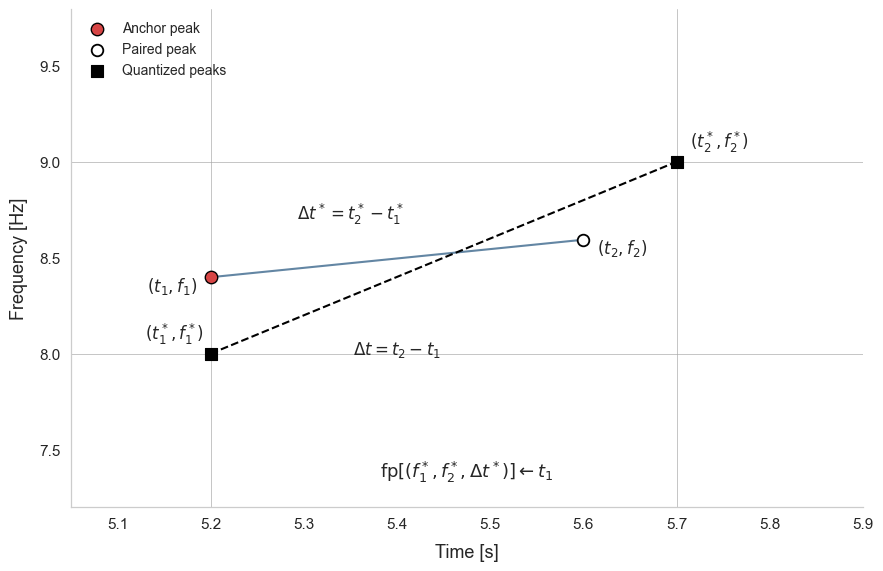

In [22]:
# =====================================================
# RIGHT: Zoomed explanation of one fingerprint
# =====================================================

# Choose ONE target for zoomed plot
target_idx = 1
t2 = target_times[target_idx]
f2 = target_freqs[target_idx]
delta_t = t2 - t1

# --- Quantization parameters (from algorithm)
freq_quantization_hz = 1.0
time_quantization_sec = 0.5
time_window_sec = 2.0

f1_bin = int(round(f1 / freq_quantization_hz))
f2_bin = int(round(f2 / freq_quantization_hz))
dt_bin = int(round(delta_t / time_quantization_sec))

f1_q = f1_bin * freq_quantization_hz
f2_q = f2_bin * freq_quantization_hz
dt_q = dt_bin * time_quantization_sec
t2_q = t1 + dt_q

# --- Axis limits (tight zoom)
t_min = t1 - 0.15
t_max = t1 + time_window_sec * 0.35
f_min = min(f1, f2) - 1.2
f_max = max(f1, f2) + 1.2


# ============================================================
# Standalone fingerprinting plot
# ============================================================
fig, ax = plt.subplots(
    figsize=(9, 6)                       # larger for PowerPoint
)

fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.13,
    top=0.96
)


# ============================================================
# Quantization grid
# ============================================================

# Frequency grid
for f in np.arange(
    np.floor(f_min),
    np.ceil(f_max) + 1,
    freq_quantization_hz
):
    ax.axhline(
        f,
        color="0.65",
        alpha=0.65,
        linewidth=0.7,
        zorder=0
    )

# Time grid
for dt in np.arange(
    0,
    time_window_sec + time_quantization_sec,
    time_quantization_sec
):
    ax.axvline(
        t1 + dt,
        color="0.65",
        alpha=0.65,
        linewidth=0.7,
        zorder=0
    )


# ============================================================
# Continuous points
# ============================================================

anchor_color = "#D64545"
connection_color = "#2F5D85"

# Anchor peak
ax.scatter(
    [t1],
    [f1],
    color=anchor_color,
    s=80,
    edgecolors="black",
    linewidths=1.0,
    zorder=5,
    label="Anchor peak"
)

# Paired peak
ax.scatter(
    [t2],
    [f2],
    marker="o",
    facecolors="white",
    edgecolors="black",
    s=70,
    linewidths=1.3,
    zorder=4,
    label="Paired peak"
)

# Continuous connection
ax.plot(
    [t1, t2],
    [f1, f2],
    color=connection_color,
    linewidth=1.5,
    alpha=0.75,
    zorder=2
)


# ============================================================
# Quantized / snapped points
# ============================================================

ax.scatter(
    [t1, t2_q],
    [f1_q, f2_q],
    marker="s",
    s=65,
    color="black",
    edgecolors="black",
    linewidths=0.8,
    zorder=5,
    label="Quantized peaks"
)

# Quantized connection
ax.plot(
    [t1, t2_q],
    [f1_q, f2_q],
    color="black",
    linewidth=1.5,
    linestyle="--",
    zorder=3
)


# ============================================================
# Coordinate annotations
# ============================================================

ax.annotate(
    r"$(t_1, f_1)$",
    (t1, f1),
    textcoords="offset points",
    xytext=(-10, -10),
    ha="right",
    fontsize=12
)

ax.annotate(
    r"$(t_2, f_2)$",
    (t2, f2),
    textcoords="offset points",
    xytext=(10, -10),
    ha="left",
    fontsize=12
)

ax.annotate(
    r"$(t_1^*, f_1^*)$",
    (t1, f1_q),
    textcoords="offset points",
    xytext=(-5, 10),
    ha="right",
    fontsize=12
)

ax.annotate(
    r"$(t_2^*, f_2^*)$",
    (t2_q, f2_q),
    textcoords="offset points",
    xytext=(10, 10),
    ha="left",
    fontsize=12
)


# ============================================================
# Δt annotations
# ============================================================

ax.text(
    (t1 + t2) / 2,
    (f1 + f2) / 2 - 0.5,
    r"$\Delta t = t_2 - t_1$",
    ha="center",
    fontsize=12
)

ax.text(
    (t1 + t2) / 2 - 0.05,
    (f1_q + f2_q) / 2 + 0.2,
    r"$\Delta t^* = t_2^* - t_1^*$",
    ha="center",
    fontsize=12
)


# ============================================================
# Fingerprint equation
# ============================================================

ax.text(
    0.5,
    0.06,
    rf"$\mathrm{{fp}}[(f_1^*,f_2^*,\Delta t^*)] \leftarrow t_1$",
    transform=ax.transAxes,
    ha="center",
    fontsize=13
)


# ============================================================
# Axes and styling
# ============================================================

ax.set_xlim(t_min, t_max)
ax.set_ylim(f_min, f_max)

ax.set_xlabel(
    "Time [s]",
    fontsize=13,
    labelpad=8
)

ax.set_ylabel(
    "Frequency [Hz]",
    fontsize=13,
    labelpad=8
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=11,
    length=4,
    width=0.8
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.9)
ax.spines["bottom"].set_linewidth(0.9)

ax.grid(False)


# ============================================================
# Legend
# ============================================================

ax.legend(
    fontsize=10,
    loc="upper left",
    frameon=False
)


# ============================================================
# Save as SVG
# ============================================================

fig.savefig(
    OUTPUT_DIR / "fingerprinting.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()